<a href="https://colab.research.google.com/github/PeteH-89/GEOG5003M_Project/blob/main/GEOG5003M_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setting up**

**Begin by installing packages, connecting to Google Drive, and importing required packages**

In [1]:
#uncomment to install packages if required
#!pip install mapclassify
#!pip install contextily
#!pip install geoplot
#!pip install git+https://github.com/pmdscully/geo_northarrow.git
#uncomment to connect to drive if required
from google.colab import drive
drive.mount('/content/drive')

# import required packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import geopandas as gpd
import pyproj
import contextily as ctx
import geoplot as gplt
import geoplot.crs as gcrs
from geo_northarrow import add_north_arrow
from sklearn import cluster
from sklearn.preprocessing import scale

warnings.filterwarnings("ignore")

Mounted at /content/drive


**Read in Data and Filter LSOAs to Only North Northamptonshire**

Using LSOA data from the Open Geography Portal (https://geoportal.statistics.gov.uk/) and Census data from https://www.nomisweb.co.uk/, read in and then use .loc to filter LSOA data to only North Northants.

In [ ]:
#read in datasets from drive
edu=pd.read_csv("/content/drive/MyDrive/GEOG5003M_Project/nnc_education.csv")
print(type(edu))
imd=pd.read_csv("/content/drive/MyDrive/GEOG5003M_Project/nnc_imd.csv")
lsoa_shp=gpd.read_file("/content/drive/MyDrive/GEOG5003M_Project/ew_lsoa.geojson")

In [ ]:
#use .head() to work out which column to filter on and then use .loc to filter lsoa data to only those within North Northamptonshire, finish by double checking everything is there using .explore
lsoa_shp.head()
nnc_lsoa=lsoa_shp.loc[lsoa_shp["LSOA21NM"].str.contains("North Northamptonshire")]
nnc_lsoa.to_file("nnc_lsoa.geojson", driver="GeoJSON")
nnc_lsoa.explore()

# **Data Exploration and Cleansing**

Check out the data we have downloaded - Look for any NAs, drop any unnecessary columns and do some basic checks on distributions etc.

In [ ]:
#start by checking dimensions of datasets, look for NAs and if present determine what to do with them (as using ONS data this is unlikely to be a problem)
print(edu.info())
print(edu.isna().sum())
print(imd.info())
print(imd.isna().sum())
print(nnc_lsoa.info())
print(nnc_lsoa.isna().sum())

All of the dataframes have 205 entries and 0 NAs, this is a good start, but the column names in the education and deprivation data need some adjustments to be usable.

In [ ]:
#rename the columns in edu and imd dataframes
edu.columns=['lsoa_name', 'lsoacode', 'pop', 'pop_pct', 'noqual_raw', 'noqual_pct', 'l1_raw', 'l1_pct', 'l2_raw', 'l2_pct', 'apprenticeship', 'apprenticeship_pct', 'l3_raw', 'l3_pct', 'l4_raw', 'l4_pct', 'other_raw', 'other_pct']
imd.columns=['lsoa_name', 'lsoacode', 'households', 'pop_pct', 'nodep_raw', 'nodep_pct', '1dim_raw', '1dim_pct', '2dim_raw', '2dim_pct', '3dim_raw', '3dim_pct', '4dim_raw', '4dim_pct']
#define as new dataframes for only percentage data with lsoa_name dropped as this is effectively duplicated by LSOA Code and only one is needed to join to geojson, pop_pct columns dropped as these are 100%. Raw population may remain useful however.
edupct=edu.drop(['lsoa_name', 'pop_pct', 'noqual_raw', 'l1_raw', 'l2_raw', 'apprenticeship', 'l3_raw', 'l4_raw', 'other_raw'], axis=1)
deppct=imd.drop(['lsoa_name', 'pop_pct', 'nodep_raw', '1dim_raw', '2dim_raw', '3dim_raw', '4dim_raw'], axis=1)
#join the two percentage tables and define as new dataframe.
edu_dep=pd.DataFrame(pd.merge(left=edupct, right=deppct, how='left', on='lsoacode'))
print(edu_dep.info())
edu_dep.describe()

The data description appears to be fairly reasonable - Our area has a blend of rural areas and small and mid sized towns and that would reasonably account for the variation between LSOAs. There is also a prison and a boarding school which is the likely reason for populations at the higher end of the distribution. One notable thing is that there are certain LSOAs without any severe (3 or 4 dimensions) deprivation. Splitting LSOAs into deciles based on percentage of households in each set of dimensions may be helpful for analysis.

In [ ]:
#using a for loop we can add the deciles only for the deprivation deciles, then we can map the deprivation deciles and see if the more deprived areas are where we would expect them to be.
#start by defining a list of the columns we want to create deciles for
#dep_cols=['nodep_pct', '1dim_pct','2dim_pct', '3dim_pct', '4dim_pct']
#now use a for loop to calculate a new column for each dep_col
#for col in dep_cols:
  #replace "pct" in new column names with "dec"
  #dec_col=col.replace('_pct', '_dec')
  #calculate 10 bins using qcut
  #edu_dep[dec_col]=pd.qcut(edu_dep[col], q=5, labels=False) + 1


**Above code results in error**

*ValueError: Bin edges must be unique: Index([0.0, 0.0, 0.0, 0.1, 0.3, 1.3], dtype='float64', name='4dim_pct'). You can drop duplicate edges by setting the 'duplicates' kwarg*


---
---

Splitting the 4 Dimensions of Deprivation column into deciles is not possible due to lack of variation between the values.


---
---


Any public good should take into account the most deprived and vulnerable, so although we will proceed with the 0, 1, 2 and 3 dimensions only for the deciles, a binary "4th Dimension" will be considered at the end and for any work based upon this analysis where prioritisation is required, agencies will be able to see where there is an additional dimension of deprivation.

In [ ]:
#using a for loop we can add the deciles only for the deprivation deciles, then we can map the deprivation deciles and see if the more deprived areas are where we would expect them to be.
#start by defining a list of the columns we want to create deciles for
dep_cols=['nodep_pct', '1dim_pct','2dim_pct', '3dim_pct']
#now use a for loop to calculate a new column for each dep_col
for col in dep_cols:
  #replace "pct" in new column names with "dec"
  dep_dec_col=col.replace('_pct', '_dec')
  #calculate 10 bins using qcut
  edu_dep[dep_dec_col]=pd.qcut(edu_dep[col], q=10, labels=False) + 1
#use "where" to add in a yes or no for whether there is additional deprivation
edu_dep['4dim_present']=np.where(edu_dep['4dim_pct']>0, 'Yes', 'No')

#now check and see if the more deprived areas are in the places they are expected to be
#define a list of the decile columns we want to check
dep_decile_cols=['nodep_dec', '1dim_dec', '2dim_dec', '3dim_dec']
#now join the decile cols to the LSOA map
#create a list that'll contain the LSOA code for indexing and then the decile columns defined in the list above
dep_only=edu_dep.loc[:,['lsoacode', 'pop', '4dim_present']+dep_decile_cols]
#use merge to combine dataframes, check resulting dataframe still has 205 rows!
lsoa_dep=nnc_lsoa.merge(dep_only, how='left', left_on='LSOA21CD', right_on='lsoacode')
#lsoa_dep.info()
#create a for loop to plot deciles for the dimensions of deprivation
for i in range (0, len(dep_decile_cols)):
  #create a plot
  fig, ax=plt.subplots(1,1,figsize=(6,6))
  #ensure columns in list are categorical
  lsoa_dep[dep_decile_cols] = lsoa_dep[dep_decile_cols].astype("category")
  #get the relevant item from the list
  lsoa_dep.plot(column=dep_decile_cols[i],
               #format the plot
               linewidth=0.1,
               categorical=True,
               legend=True,
               cmap='RdBu_r',
               ax=ax,
               legend_kwds={'loc': 'center left', 'bbox_to_anchor':(1,0.5), 'title': 'Decile'})
  #add a pink outline to the LSOAs where there are households deprived in four dimensions
  four_dim=lsoa_dep.loc[lsoa_dep['4dim_present']=='Yes']
  four_dim.boundary.plot(linewidth=.5,
                color='magenta',
                alpha=.8,
                ax=ax)
  #add a title based on column, remove axis
  plt.title(dep_decile_cols[i].replace('nodep_dec', 'No Dimension').replace('dim_dec',' Dimensions').capitalize()+' of Deprivation in North Northamptonshire (Decile)')
  plt.axis('off')

The most deprived areas are where we'd expect them to be: In the urban areas, particularly in Corby, Kettering and Wellingborough. Interestingly even in the areas where there is very little other deprivation, there are still some households deprived in four dimensions.

This is likely an effect of the fact that we are working with LSOAs, and especially in more rural areas these are rather large spatial units. If this was run again using OAs instead we would be able to more accurately tell exactly where the deprived households are present.

Now following the same process as above with the education data.

In [ ]:
#using a for loop we can add the deciles for education, then we can map the education deciles and see if the more educated areas are where we would expect them to be.
#start by defining a list of the columns we want to create deciles for
edu_cols=['noqual_pct', 'l1_pct', 'l2_pct', 'apprenticeship_pct', 'l3_pct', 'l4_pct', 'other_pct']
#now use a for loop to calculate a new column for each dep_col
for col in edu_cols:
  #replace "pct" in new column names with "dec"
  ed_dec_col=col.replace('_pct', '_dec')
  #calculate 10 bins using qcut
  edu_dep[ed_dec_col]=pd.qcut(edu_dep[col], q=10, labels=False) + 1
#now check and see if the more deprived areas are in the places they are expected to be
#define a list of the decile columns we want to check
edu_cols=['noqual_dec', 'l1_dec', 'l2_dec', 'apprenticeship_dec', 'l3_dec', 'l4_dec', 'other_dec']
#now join the decile cols to the LSOA map
#create a list that'll contain the LSOA code for indexing and then the decile columns defined in the list above
edu_only=edu_dep.loc[:,['lsoacode', 'pop']+edu_cols]
#use merge to combine dataframes, check resulting dataframe still has 205 rows!
lsoa_edu=nnc_lsoa.merge(edu_only, how='left', left_on='LSOA21CD', right_on='lsoacode')
#lsoa_dep.info()
#create a for loop to plot deciles for the dimensions of deprivation
for i in range (0, len(edu_cols)):
  #create a plot
  fig, ax=plt.subplots(1,1,figsize=(6,6))
  #ensure columns in list are categorical
  lsoa_edu[edu_cols] = lsoa_edu[edu_cols].astype("category")
  #get the relevant item from the list
  lsoa_edu.plot(column=edu_cols[i],
               #format the plot
               linewidth=0.1,
               categorical=True,
               legend=True,
               cmap='RdBu_r',
               ax=ax,
               legend_kwds={'loc': 'center left', 'bbox_to_anchor':(1,0.5), 'title': ' Decile'})
  #add a title based on column, remove axis
  plt.title(edu_cols[i].replace('noqual', 'No Qualification').replace('l1', 'Level 1').replace('l2', 'Level 2').replace('l3', 'Level 3').replace('l4', 'Level 4').replace('_dec', ' % (Decile)').capitalize())
  plt.axis('off')

At a glance it appears that the areas with the highest prevalence of deprivation are those with either no or lower levels of education. Now we'll combine those dataframes and examine the relationships further.

# Analysing the Deprivation Data by Highest Qualification Completed

Start by combining the decile data with the most common highest qualification for the LSOA

In [ ]:
#merge the dataframes created for the deprivation data and the education percentages
depdec_edupct=pd.DataFrame(dep_only.merge(edupct, 'left', on='lsoacode').drop('pop_y', axis=1))
depdec_edupct.head()

In [ ]:
#create a list only of the percentage and decile columns and plot as pairplot
pairplot_columns=['noqual_pct', 'l1_pct', 'l2_pct', 'apprenticeship_pct', 'l3_pct', 'l4_pct', 'other_pct', 'nodep_dec', '1dim_dec','2dim_dec', '3dim_dec']
sns.pairplot(depdec_edupct[pairplot_columns], height=4);

Possibly due to the smaller dataset, the pairplot isn't particularly useful. May be worth examining deprivation based on most common highest qualification.

In [ ]:
###Initial idea didn't work so well, left in por posterity/the edu_cols list/may be useful later on###
#use idxmax to return most common highest qualification for the lsoa
edu_cols=['noqual_pct', 'l1_pct', 'l2_pct', 'apprenticeship_pct', 'l3_pct', 'l4_pct', 'other_pct']
#depdec_edupct['highqual']=depdec_edupct[edu_cols].idxmax(axis=1)
#strip the '_pct'
#depdec_edupct['highqual']=depdec_edupct['highqual'].str.replace('_pct', '')
#pivot dataframe to allow for plotting of distributions
plot_data=pd.melt(depdec_edupct, id_vars=['lsoacode']+dep_decile_cols, value_vars=edu_cols, var_name='qual', value_name='percentage')
#pivot the deprivation decile
plot_data=pd.melt(plot_data, id_vars=['lsoacode', 'qual', 'percentage'], value_vars=dep_decile_cols, var_name='dep_decile', value_name='decile')
#clean up the strings in the columns
plot_data['qual']=plot_data['qual'].str.replace('_pct', '')
plot_data['dep_decile']=plot_data['dep_decile'].str.replace('_dec', '')
#check it looks how we expect
print(plot_data.info())
print(plot_data.head())

## Non Spatial Visualisation

The chosen visualisation is a violin plot with deciles along the x-axis and percentage of each qualification on the y-axis. This is to examine the distributions of qualifications within each decile and to try to gain some broad insight into trends that may be present. Although it would be expected that either a lack of qualifications or lower levels would predominate in areas with higher deprivation and vice versa, this is a good visual tool for checking that assumption.

In [ ]:
#plot the data as a violin plot to show data distributions
#sns.catplot(data=plot_data, x='decile', y='percentage', hue='qual', kind='violin', height=4, aspect=3);
#This plot is really wide and hard to interpret. May be best to split into top/bottom and plot the 1-5 on one and the 6-10 on another
top_plot=plot_data.loc[plot_data['decile']<=5]
bottom_plot=plot_data.loc[plot_data['decile']>5]
#create subplots
fig, ax=plt.subplots(2,1, figsize=(24, 12))
#add title
fig.suptitle('Distribution of Highest Qualification Attained by Deprivation Decile in North Northamptonshire')
#map the top and bottom plots onto the subplots
sns.violinplot(data=top_plot, x='decile', y='percentage', hue='qual', legend=False, ax=ax[0])
ax[0].set_xlabel('')
ax[0].set_ylabel('Highest Qualification (%)')
sns.violinplot(data=bottom_plot, x='decile', y='percentage', hue='qual', ax=ax[1])
ax[1].set_xlabel('Deprivation Decile')
ax[1].set_ylabel('Highest Qualification (%)')
#add legend
#change legend labels
leg_labels=['No Qualification', 'Level 1', 'Level 2', 'Apprenticeship' ,'Level 3', 'Level 4', 'Other']
#remove legend from ax[1]
ax[1].legend_.remove()
handles, labels = ax[1].get_legend_handles_labels()
fig.legend(handles, leg_labels, title='Qualification', loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=4);

Qualifications are distriuted roughly as we'd expect - LSOAs in higher deprivation deciles show a higher distribution of No Qualification and lower distribution of Level 4 qualifications. This is reversed in lower deprivation deciles.

Apprenticeships appear to be fairly evenly distributed across all deprivation deciles, which seems reasonable as it could represent tradespeople at different stages of their careers.

**How do the data correlate?**

Using a Spearman's Rank Correlation we can quantify the association between the deprivation deciles and the qualifications attained

In [ ]:
#calculate the correlation
edu_dep_corr=depdec_edupct[['noqual_pct', 'l1_pct', 'l2_pct', 'apprenticeship_pct', 'l3_pct', 'l4_pct', 'other_pct', 'nodep_dec', '1dim_dec','2dim_dec', '3dim_dec']].corr(method='spearman')
edu_dep_corr

In [ ]:
#plot spearman correlation on heatmap, this is adapted from week 7 exercise notes
#define plot size
fig,ax = plt.subplots(figsize=(8,8))

#define mask to apply to upper right hand corner of the plot
data_to_mask = np.triu(np.ones_like(edu_dep_corr))

#define axis tick labels
#get the index and the columns, replace the underscores with spaces and remove 'domain ' from the name
x_axis_labels = edu_dep_corr.columns.str.replace('dim_dec',
                                                 ' Dimensions').str.replace('noqual_pct',
                                                  'No Qualification').str.replace('l1_pct', 'Level 1').str.replace('l2_pct',
                                                  'Level 2').str.replace('l3_pct', 'Level 3').str.replace('l4_pct',
                                                  'Level 4').str.replace('_dec', ' ').str.replace('nodep', 'No Deprivation').str.replace('apprenticeship_pct',
                                                  'Apprenticeship').str.replace('other_pct', 'Other')
y_axis_labels = edu_dep_corr.columns.str.replace('dim_dec',
                                                 ' Dimensions').str.replace('noqual_pct',
                                                  'No Qualification').str.replace('l1_pct', 'Level 1').str.replace('l2_pct',
                                                  'Level 2').str.replace('l3_pct', 'Level 3').str.replace('l4_pct',
                                                  'Level 4').str.replace('_dec', ' ').str.replace('nodep', 'No Deprivation').str.replace('apprenticeship_pct',
                                                  'Apprenticeship').str.replace('other_pct', 'Other')


# plot a heatmap of the correlation dataframe
sns.heatmap(edu_dep_corr,
            # annotate so spearman's rank correlation values are displayed on the squares
            annot=True,
            # define colourmap
            cmap='RdBu',
            # define value of minimum colour on cbar
            vmin=-1,
            # define value of maximum colour on cbar
            vmax=1,
            # add the mask
            mask=data_to_mask,
            #add thin white line between squares
            linewidths=0.1,
            # use the custom tick labels
            xticklabels=x_axis_labels,
            yticklabels=y_axis_labels,
            # add a label to the cbar
            cbar_kws={'label': "Spearman's Rank correlation"},
            # plot on the axis we defined
            ax=ax)

# Set axis labels
ax.set(xlabel='Highest Qualification Gained (%) and Dimensions of Deprivation (Decile)',
       ylabel='Highest Qualification Gained (%) and Dimensions of Deprivation (Decile)',
      title ='Correlation between Highest Qualification Gained and Deprivation Dimensions'+'\n'+'in North Northamptonshire');

As surmised from the violin plots, apprenticeships correlate only fairly weakly with any kind of deprivation. People holding Level 4 qualifications tend not to correlate with more deprived areas, whereas those individuals with no qualifications are shown to have a strongly negative correlation to areas with no deprivation. This is roughly as expected.

# K-Means Clustering

To investigate any deeper associations between these data, K Means clustering can be used. This may help uncover som things that haven't been revealed by the analysis thus far.

In [ ]:
#begin by identifying number of clusters using elbow method
sum_of_squares=[]
#create 'K', a range of numbers from 1-15
K=range(1,15)
#and use it to create a for loop that generates a model with K clusters
for k in K:
  #set random state
  km=cluster.KMeans(n_clusters=k, init='random', random_state=1453)
  #feed in variables
  km=km.fit(depdec_edupct[['noqual_pct', 'l1_pct', 'l2_pct', 'apprenticeship_pct',
                           'l3_pct', 'l4_pct', 'other_pct', 'nodep_dec', '1dim_dec',
                           '2dim_dec', '3dim_dec']].values)
  #calculate sum of squared distances, append to list created above
  sum_of_squares.append(km.inertia_)
# plot the sum of squared distances against the number of clusters
plt.plot(K, sum_of_squares, 'bx-')
plt.title('Elbow Checking')
plt.xlabel('K')
plt.ylabel('Sum of Square Distance');

5 or 6 looks to be the elbow, and it appears that **5** is where the substantive reduction ends, the reduction in distance is much less significant beyond this point.

In [ ]:
#run 5 cluster model
km5=cluster.KMeans(n_clusters=5, init='random', random_state=1453)
#feed in variables
km5cls=km5.fit(depdec_edupct[['noqual_pct', 'l1_pct', 'l2_pct', 'apprenticeship_pct',
                         'l3_pct', 'l4_pct', 'other_pct', 'nodep_dec', '1dim_dec',
                          '2dim_dec', '3dim_dec']].values)
#check the labels
print(km5cls.labels_)
#add cluster to dataframe
depdec_edupct['cluster']=km5cls.labels_
depdec_edupct['cluster'].head()

Run a pairplot to see if there are any deeper insights available

In [ ]:
sns.pairplot(depdec_edupct[['noqual_pct', 'l1_pct', 'l2_pct', 'apprenticeship_pct',
                           'l3_pct', 'l4_pct', 'other_pct', 'nodep_dec', '1dim_dec',
                           '2dim_dec', '3dim_dec', 'cluster']],
             hue='cluster')

# Check Spatial Distributions of Clusters

Earlier initial analysis seemed to show that the areas of lower education generally matched with areas of higher than average household deprivation.

Mapping the K-means clusters could show if this relationship bears out or if circumstances vary across deprived areas.

In [ ]:
#join the depdec_edupct to the spatial dataframe
plot_lsoa=nnc_lsoa.merge(depdec_edupct, 'left', left_on='LSOA21CD', right_on='lsoacode')
#plot_lsoa.head()
#map the clusters
f, ax = plt.subplots(1, figsize=(9, 9))
plot_lsoa.plot(column='cluster', categorical=True, legend=True, ax=ax)
ax.set_axis_off();

Compare Clusters Using Summary Statistics

In [ ]:
#get median values by cluster
nnc_cluster_median=plot_lsoa.groupby('cluster')[['noqual_pct', 'l1_pct', 'l2_pct', 'apprenticeship_pct',
                           'l3_pct', 'l4_pct', 'other_pct', 'nodep_dec', '1dim_dec',
                           '2dim_dec', '3dim_dec']].median().reset_index()
nnc_cluster_median

In [ ]:
#melt datafarame to plot
nnc_cluster_med_plot=pd.melt(nnc_cluster_median, id_vars='cluster',
                             value_vars=['noqual_pct', 'l1_pct', 'l2_pct', 'apprenticeship_pct',
                           'l3_pct', 'l4_pct', 'other_pct', 'nodep_dec', '1dim_dec',
                           '2dim_dec', '3dim_dec'])
#nnc_cluster_med_plot.info()
nnc_cluster_med_plot.columns=['Cluster', 'Variable', 'Median']
nnc_cluster_med_plot.head()

Plotting faceted bar charts we can see what each cluster represents

In [ ]:
#use a bar chart
sns.catplot(nnc_cluster_med_plot, row='Cluster', y='Variable', x='Median', kind='bar', aspect=4, hue='Median')

Name the clusters using the summaries

In [ ]:
#create an empty column
plot_lsoa['cluster_description']=""
#for each cluster add a cluster description
plot_lsoa.loc[plot_lsoa['cluster']==0, 'cluster_description']= 'Diversely Educated, Doing Okay'
plot_lsoa.loc[plot_lsoa['cluster']==1, 'cluster_description']= 'Educated Urban Extensions and Outlying Villages'
plot_lsoa.loc[plot_lsoa['cluster']==2, 'cluster_description']= 'Less Educated and Highly Deprived'
plot_lsoa.loc[plot_lsoa['cluster']==3, 'cluster_description']= 'Well Educated Rural Dwellers'
plot_lsoa.loc[plot_lsoa['cluster']==4, 'cluster_description']= 'Blend of Qualifications, Possibly Struggling'

Map the clusters with descriptions

In [ ]:
#start by defining colour mapping
#using wong palette, sourced from here: https://davidmathlogic.com/colorblind/#%23000000-%23E69F00-%2356B4E9-%23009E73-%23F0E442-%230072B2-%23D55E00-%23CC79A7
custom_colour=['#F0E442', '#56B4E9', '#009E73', '#D55E00', '#0072B2']

In [ ]:
#plot cluster descriptions using newly defined colour map
cluster_map=plot_lsoa.sort_values('cluster_description').explore('cluster_description', categorical=True, cmap=custom_colour)
cluster_map

Based upon local knowledge, this looks broadly as expected, the most deprived areas are in Corby, parts of Kettering and Wellingborough as well as parts of Rushden and Raunds. Towns which are larger and more diverse, and the areas it picks out are the more deprived areas of those towns.

Where qualifications are blended and there may be some level of deprivation, this is likely down to the modifiable aerial unit problem - The LSOA contains a spatially close but socioeconomically diverse population.

The category "Educated Urban Extensions & Outlying Villages" shows a distribution around the key towns, possibly signifying people who either work in town and have moved to one of the outlying villages, or who have moved into one of the housing estates built on the urban fringes. Alternately, these are generally within commuting distance of railway stations (Corby, Kettering, Wellingborough and Market Harborough) and so could represent educated London workers who have moved to a lower cost of living area.

"Diversely Educated, Doing Okay" seems to represent a similar diversity of education to "Blend of Qualifications, Possibly Struggling" but with a lower median deprivation decile in each dimension. These areas tend to predominantly occur in smaller towns and around the edges of the larger towns in areas which have seen less development overall, when compared to "Educated Urban Extensions and Outlying Villages" that may suggest a more established and stable population.

The final category, "Well Educated Rural Dwellers" may prove problematic to an extent as it risks erasing rural poverty. There are deprived populations within rural areas that due to the size of the LSOAs in these areas may be missed.

## Final output map - Add basemap, north arrow, title and a proper legend

In [ ]:
# convert CRS to epsg=3857 Web Mercator
plot_lsoa=plot_lsoa.to_crs(epsg=3857)
fig,ax = plt.subplots(1, figsize=(10,10))
# plot the Leeds data as usual
plot_lsoa.plot(column='cluster_description', cmap='tab10_r', legend=True, alpha=0.8, ax=ax)
# add ctx basemap to ax
ctx.add_basemap(ax)
#move legend to bottom
leg = ax.get_legend()
leg.set_bbox_to_anchor((1,0))
leg.set_title('K-Means Cluster')
#set plot title
ax.set_title('North Northamptonshire Deprivation and Education'+'\n'+'K-Means Clusters')
ax.set_axis_off()
#add north arrow
add_north_arrow(ax=ax, scale=.75, xlim_pos=0.1, ylim_pos=.85, color='#000', text_scaler=2, text_yT=-1.25)

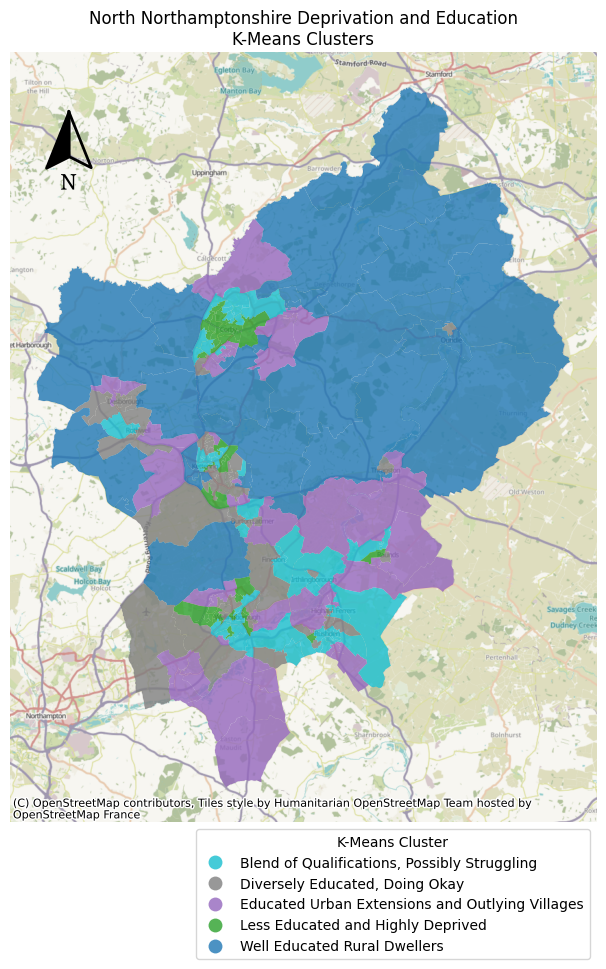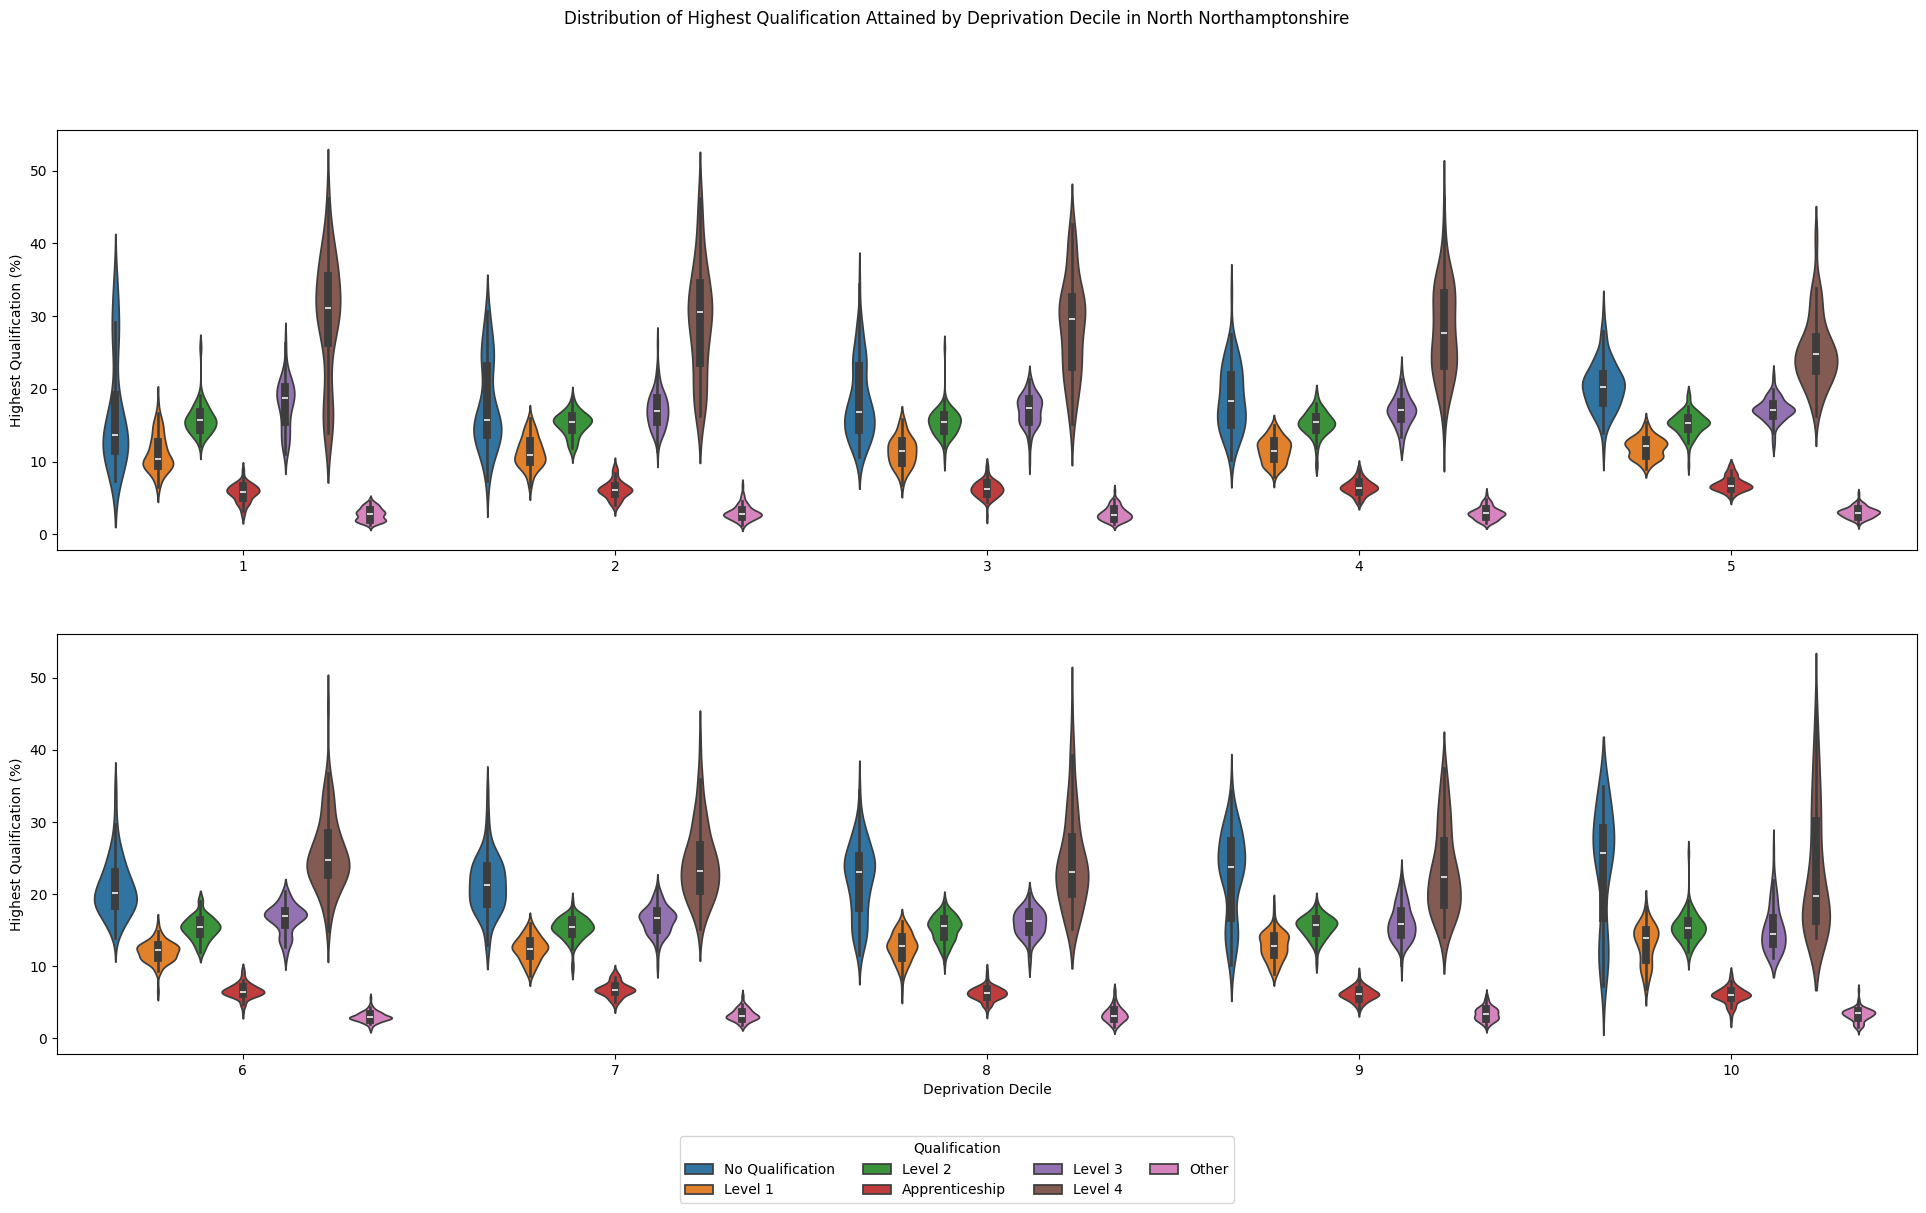